Dataset Preview:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape: (1338, 7)

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

===== MULTIPLE LINEAR REGRESSION =====
MAE: 4181.194473753651
MSE: 33596915.851361476
RMSE: 5796.284659276274
R2 Score: 0.7835929767120722

===== RIDGE REGRESSION =====
MAE: 4182.796596583267
MSE: 33604973.53996331
RMSE: 5796.979691180858
R2 Score: 0.7835410749121385

===== LASSO REGRESSION =====
MAE: 4181.197631564924
MSE: 33596958.0103243
RMSE: 5796.288295998078
R2 Score: 0.7835927051545373

===== RIDGE HYPERPARAMETER TUNING =====
Best 

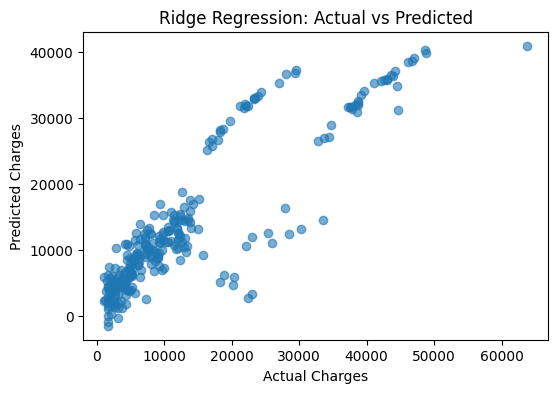

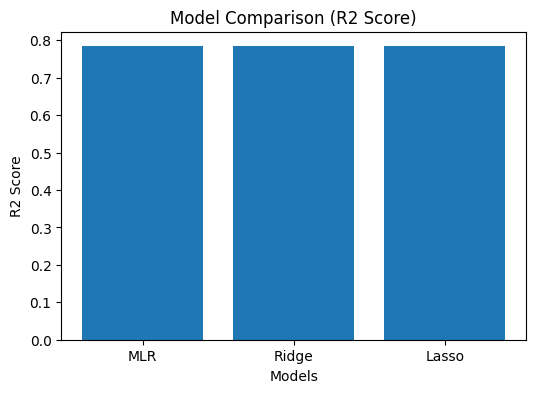

In [3]:
# =====================================
# STEP 1: Import Libraries
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================
# STEP 2: Load Dataset
# =====================================
df = pd.read_csv("/content/insurance.csv")
print("Dataset Preview:\n", df.head())
print("\nDataset Shape:", df.shape)

# =====================================
# STEP 3: Data Preprocessing
# =====================================
print("\nMissing Values:\n", df.isna().sum())

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# =====================================
# STEP 4: Features & Target
# Target = charges
# =====================================
X = df_encoded.drop(columns=["charges"])
y = df_encoded["charges"]

# =====================================
# STEP 5: Train-Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# STEP 6: Feature Scaling
# =====================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================
# PART A: Multiple Linear Regression
# =====================================
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_test_scaled)

print("\n===== MULTIPLE LINEAR REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_mlr))
print("MSE:", mean_squared_error(y_test, y_pred_mlr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlr)))
print("R2 Score:", r2_score(y_test, y_pred_mlr))

# =====================================
# PART B: Ridge Regression
# =====================================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("\n===== RIDGE REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

# =====================================
# PART C: Lasso Regression
# =====================================
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("\n===== LASSO REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

# =====================================
# PART D: Hyperparameter Tuning (Ridge & Lasso)
# =====================================
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring="r2")
ridge_grid.fit(X_train_scaled, y_train)

print("\n===== RIDGE HYPERPARAMETER TUNING =====")
print("Best Alpha:", ridge_grid.best_params_)
print("Best CV R2:", ridge_grid.best_score_)

lasso_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring="r2")
lasso_grid.fit(X_train_scaled, y_train)

print("\n===== LASSO HYPERPARAMETER TUNING =====")
print("Best Alpha:", lasso_grid.best_params_)
print("Best CV R2:", lasso_grid.best_score_)

# =====================================
# PART E: REQUIRED GRAPHS ONLY
# =====================================

# Graph 1: Actual vs Predicted (Best model: Ridge)
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_ridge, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

# Graph 2: Model Comparison (R2 Score)
models = ["MLR", "Ridge", "Lasso"]
r2_scores = [
    r2_score(y_test, y_pred_mlr),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.figure(figsize=(6,4))
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")
plt.show()
